# Predicting Wine Quality from Physicochemical Properties

**DSCI 310 Group 03**
* Arnav Gupta
* Ashley Chan
* Jake Andersen-Lum
* Nathan Shack

## Summary

This project investigates whether the quality of wine can be predicted from its physicochemical properties using a K-Nearest Neighbors (KNN) regression approach. We use the Wine Quality dataset from the UCI Machine Learning Repository (Cortez et al., 2009), which contains physicochemical measurements and sensory quality ratings for Portuguese "Vinho Verde" wine samples. We train a KNN regression model to predict wine quality scores from features such as alcohol content, acidity, pH, and residual sugar.

## Introduction

<!-- TODO (Arnav): Write the introduction section. It should include:
  - Background information on wine quality assessment and what physicochemical
    properties of wine are (so a reader unfamiliar with the topic can follow along)
  - Clearly state the predictive question: "Can we predict the quality score
    of a wine based on its physicochemical properties?"
  - Describe the Wine Quality dataset (UCI ML Repository, Cortez et al., 2009):
    - Source: Portuguese "Vinho Verde" wine samples
    - Contains 11 physicochemical features and a quality rating (0-10)
    - We combine the red and white wine datasets
    - We use KNN regression to predict the quality score
-->

## Methods & Results

### Data Loading

We load the Wine Quality dataset directly from the UCI Machine Learning Repository using the `ucimlrepo` package. This ensures the data is reproducibly downloaded from the original source.

In [15]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch the Wine Quality dataset from UCI ML Repository (ID: 186)
wine_quality = fetch_ucirepo(id=186)

# Combine features and target into a single DataFrame
wine_df = pd.concat([wine_quality.data.features, wine_quality.data.targets], axis=1)

# Preview the data
wine_df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
# Basic info about the dataset
print(f"Dataset shape: {wine_df.shape}")
print(f"\nColumn types:\n{wine_df.dtypes}")
print(f"\nMissing values:\n{wine_df.isnull().sum()}")
print(f"\nQuality score distribution:\n{wine_df['quality'].value_counts().sort_index()}")

Dataset shape: (6497, 12)

Column types:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Quality score distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


### Data

The Wine Quality dataset contains physicochemical properties and sensory quality ratings of red and white wines. Each row represents a single wine sample, with 11 continuous features describing chemical characteristics such as fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, sulfur dioxide, density, pH level, sulphates, and alchohol levels. The target variable, `quality`, is an ordinal score from 3-9 assigned by human tasters based on sensory evaluation.


Table 1. Predictor variables used for analysis
| Variable             | Role    | Type       | Missing | Description                                                                    |
| -------------------- | ------- | ---------- | ------- | ------------------------------------------------------------------------------ |
| fixed_acidity        | Feature | Continuous | No      | Amount of fixed (non-volatile) acids; mainly tartaric acid (g/dm³)             |
| volatile_acidity     | Feature | Continuous | No      | Amount of acetic acid; high levels lead to a vinegar taste (g/dm³)             |
| citric_acid          | Feature | Continuous | No      | Small quantities add freshness and flavour (g/dm³)                             |
| residual_sugar       | Feature | Continuous | No      | Sugar remaining after fermentation stops (g/dm³)                               |
| chlorides            | Feature | Continuous | No      | Amount of salt in the wine (g/dm³)                                             |
| free_sulfur_dioxide  | Feature | Continuous | No      | Free form of SO₂; prevents microbial growth and oxidation (mg/dm³)             |
| total_sulfur_dioxide | Feature | Continuous | No      | Total SO₂ (free + bound); detectable above 50 mg/L (mg/dm³)                    |
| density              | Feature | Continuous | No      | Density of the wine, close to water depending on alcohol/sugar content (g/cm³) |
| pH                   | Feature | Continuous | No      | Acidity on a 0–14 scale; most wines fall between 3–4                           |
| sulphates            | Feature | Continuous | No      | Additive contributing to SO₂ levels; acts as antimicrobial agent (g/dm³)       |
| alcohol              | Feature | Continuous | No      | Percentage of alcohol by volume (% vol)                                        |
| quality              | Target  | Ordinal    | No      | Wine quality score assigned by sensory evaluation (integer, 0–10)              |




### Data Wrangling

The Wine Quality dataset comes relatively clean with no missing values. We combine the features and target into a single DataFrame and save the processed data for downstream analysis.

In [ ]:
# Save processed data to data/ directory

import os

file_path = "../data/wine_quality_processed.csv"

if not os.path.exists(file_path): #check to see if file is already downloaded
    wine_df.to_csv(file_path, index=False)
    print(f"Processed data saved to {file_path}")
else:
    print(f"File already exists: {file_path}")
    

print(f"Dataset shape: {wine_df.shape}")

File already exists: ../data/wine_quality_processed.csv
Dataset shape: (6497, 12)


### Exploratory Data Analysis


<!-- TODO (Ashley): Add EDA here. Suggestions:
  - Summary statistics table for the features (wine_df.describe())
  - A visualization showing the distribution of quality scores
  - Scatter plots of key features vs quality
    (e.g., alcohol vs quality, volatile_acidity vs quality)
  - A correlation heatmap of the features
  - Brief written narration explaining what the visualizations show
-->

#### Summary Statistics

The output below provides summary statistics for all numeric features in the dataset, including count, mean, standard deviation, minimum, maximum, and quartiles (25%, 50%, 75%) for each variable. This provides a quick glance at the general spread and range of the features in the dataset. 

Most wines have moderate acidity, low volatile acidity, and around 9-11% alcohol, with a median quality of 6. 

In [18]:
wine_df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


##### Distribution of Wine Quality

Below is a distrubution of wine quality scores as a bar chart, showing how many wines in the dataset fall into each quality category.

The target variable, Wine Quality, is approximately normally distributed, with a mean of 5.8 and a mode of 6. Most wines fall in the mid-quality range of 5–7, indicating that extremely low or high quality wines are less common.

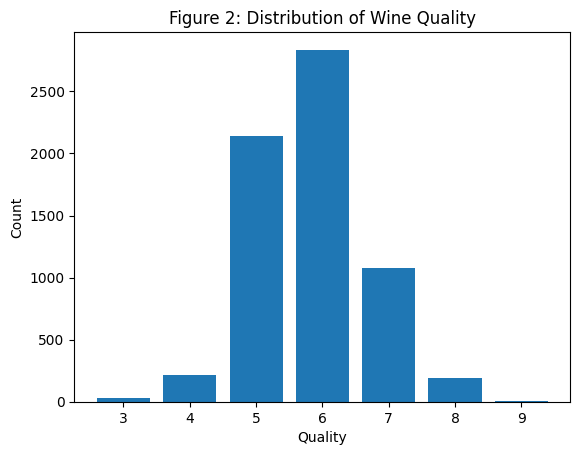

Quality Counts of Wine Quality: quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64
Mean Wine Quality: 5.8
Median Wine Quality: 6.0
Most Frequent Wine Quality: 6
Standard Deviation of Wine Quality: 0.8732552715311248


In [38]:
import matplotlib.pyplot as plt

quality_counts = wine_df['quality'].value_counts()

plt.bar(quality_counts.index, quality_counts.values)
plt.title('Figure 2: Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

print(f"Quality Counts of Wine Quality: {quality_counts}")
print(f"Mean Wine Quality: {wine_df['quality'].mean():.2g}")
print(f"Median Wine Quality: {wine_df["quality"].median()}")
print(f"Most Frequent Wine Quality: {wine_df['quality'].mode()[0]}")
print(f"Standard Deviation of Wine Quality: {wine_df['quality'].std()}")


##### Correlation Heatmap of Wine Features

This correlation heatmap visualizes the correlation between all features within the wine dataset.

We can see that the features `density` and `alcohol` have a strong inverse relationship (-0.69). `total_sulfur_dioxide` is strongly correlated with `free_sulfur_dioxide` (+0.72), which makes sense since the free sulfur dioxide is included in the total amount. `residual_sugar` shows moderate correlations with `total_sulfur_dioxide`, `free_sulfur_dioxide`, and `density`. The target variable `quality` has its strongest relationships with `alcohol` (+0.44) and `volatile_acidity` (-0.27), suggesting that these features may be particularly important for predicting wine quality.

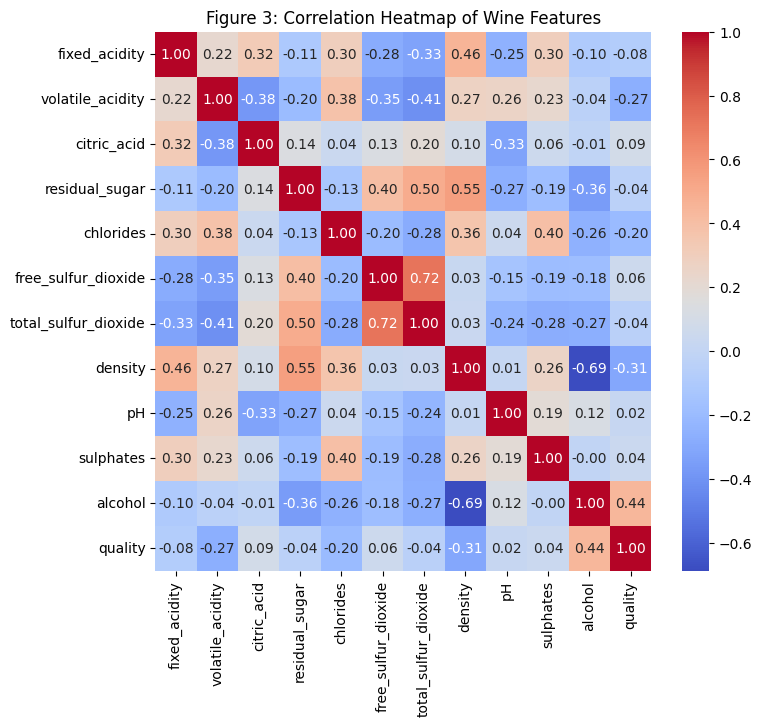

In [39]:
import seaborn as sns

plt.figure(figsize=(8, 7))
sns.heatmap(wine_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Figure 3: Correlation Heatmap of Wine Features')
plt.show()

##### Correlation of Alcohol and Quality

The box plots show the distribution of alcohol content for each wine score.

We can observe a slight positive correlation between Wine Quality and alcohol content. Higher-quality wines (7, 8, 9) generally have higher mean alcohol levels. Interestingly, the mean alcohol content decreases slightly for lower-quality wines (3–5) and then begins to increase from quality 6 onward.

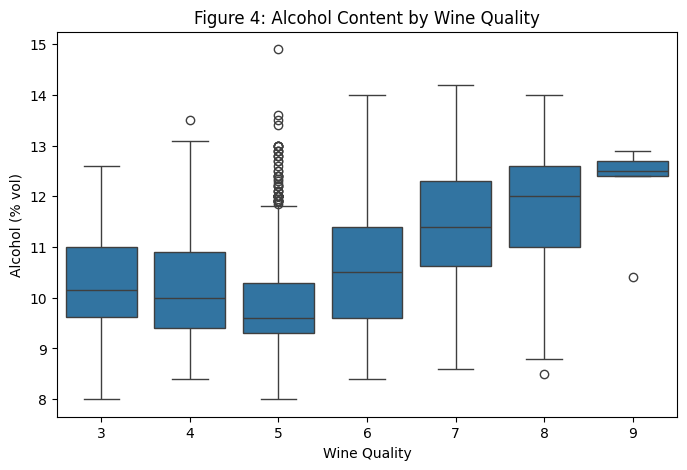

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='alcohol', data=wine_df)
plt.title('Figure 4: Alcohol Content by Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Alcohol (% vol)')
plt.show()

### Regression Analysis

<!-- TODO (Ashley): Add the regression model here. Suggestions:
  - Split data into training and test sets
  - Standardize/scale the features
  - Perform KNN regression with cross-validation to select K
  - Evaluate model performance on the test set (RMSE, R²)
  - Create a visualization of the results (e.g., predicted vs actual,
    RMSE vs K plot)
  - Brief written narration of the model building process and results
-->

We will perform K-Nearest Neighbors (KNN) regression to predict wine quality based on the chemical features of the wines. The dataset will be split into a training set and a 30% test set, and a pipeline will be used to preprocess and scale all features. We will then conduct a grid search to select the optimal number of neighbors (K) and evaluate the model’s performance on the test set to assess its predictive accuracy.

#### Splitting the Data into Training & Testing Sets 

The dataset will be split into 70% training data and 30% test data

In [33]:
from sklearn.model_selection import train_test_split

# Features and target
X = wine_df.drop(columns=['quality'])
y = wine_df['quality']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")
X_train.head()


X_train size: (4547, 11)
X_test size: (1950, 11)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
2457,6.7,0.22,0.39,10.2,0.038,60.0,149.0,0.99725,3.17,0.54,10.0
524,9.2,0.43,0.49,2.4,0.086,23.0,116.0,0.99760,3.23,0.64,9.5
4551,6.1,0.27,0.25,1.8,0.041,9.0,109.0,0.99290,3.08,0.54,9.0
5954,6.4,0.31,0.28,2.5,0.039,34.0,137.0,0.98946,3.22,0.38,12.7
3759,6.0,0.33,0.38,9.7,0.040,29.0,124.0,0.99540,3.47,0.48,11.0


#### Creating a Pipeline

Since all the features in our dataset are numeric but may have different ranges and units, we will standardize them so that each feature contributes equally to the distance calculations in the K-Nearest Neighbors model. This scaling step ensures that features with larger numerical values do not dominate the model and allows the algorithm to measure similarity between samples more accurately.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline

scaler = StandardScaler()
model = KNeighborsRegressor()
pipe = make_pipeline(scaler, model)

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kneighborsregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tr

#### Grid Search for best K with Cross Validation

We will perform a grid seearch to identify the optimal number of neighbours (K) for the K-Nearest Neighbors regression model. This involves evaluating a range of K values between 1 and 29 using cross validation on the training set to measure model performance. The best performing value of K will be used to fit the final model and evaluate its performance on the test set,

In [24]:
from sklearn.model_selection import GridSearchCV

k_values = range(1,30) # try K=1 to 29

param_grid = {'kneighborsregressor__n_neighbors': list(k_values)}  

grid = GridSearchCV(pipe, param_grid, n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

best_k = grid.best_params_['kneighborsregressor__n_neighbors']
best_cv_score = grid.best_score_
best_model = grid.best_estimator_
best_train_score = best_model.score(X_train, y_train)

print(f"Best Model: {best_model}")
print()
print(f"Best K: {best_k}")
print(f"Best CV Score: {best_cv_score:.5g}")
print(f"Best Train Score: {best_train_score:.5g}")

Best Model: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsregressor', KNeighborsRegressor(n_neighbors=21))])

Best K: 21
Best CV Score: 0.34352
Best Train Score: 0.41222


In [45]:
results = pd.DataFrame(grid.cv_results_)
results = pd.DataFrame(grid.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']
]

print("Figure 5: Results of Grid Search Cross Validation")
results

Figure 5: Results of Grid Search Cross Validation


,params,mean_test_score,std_test_score,mean_train_score,std_train_score
0,{'kneighborsregressor__n_neighbors': 1},0.092826,0.069927,1.000000,0.000000
1,{'kneighborsregressor__n_neighbors': 2},0.230754,0.038078,0.779557,0.003860
2,{'kneighborsregressor__n_neighbors': 3},0.286078,0.026086,0.668196,0.002550
3,{'kneighborsregressor__n_neighbors': 4},0.319000,0.023478,0.605030,0.005425
4,{'kneighborsregressor__n_neighbors': 5},0.330007,0.021589,0.564269,0.006124
5,{'kneighborsregressor__n_neighbors': 6},0.334799,0.027805,0.536615,0.004802
6,{'kneighborsregressor__n_neighbors': 7},0.335600,0.031329,0.515438,0.003305
7,{'kneighborsregressor__n_neighbors': 8},0.339080,0.034541,0.498159,0.005880
8,{'kneighborsregressor__n_neighbors': 9},0.339135,0.036526,0.481017,0.007277
9,{'kneighborsregressor__n_neighbors': 10},0.339148,0.034313,0.469061,0.007079


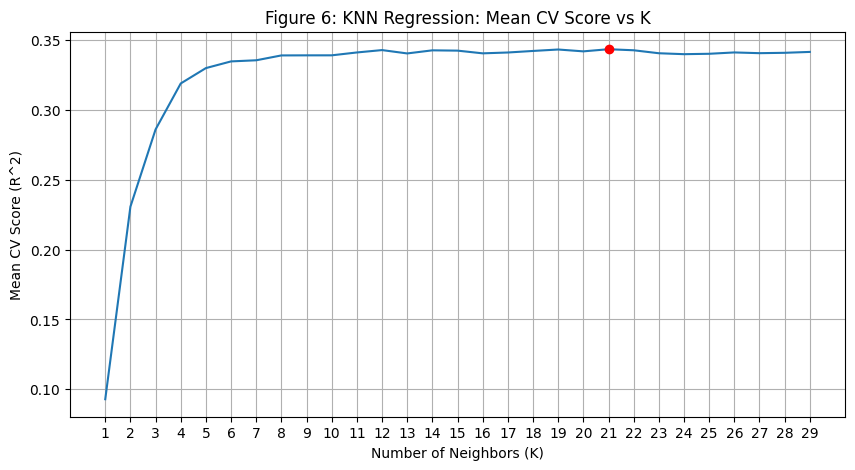

In [46]:
plt.figure(figsize=(10,5))
plt.plot(k_values, results['mean_test_score'])
plt.scatter(best_k, best_cv_score, color='red', zorder=5)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean CV Score (R^2)')
plt.title('Figure 6: KNN Regression: Mean CV Score vs K')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [47]:
print(f"Best Model: {best_model}")
print()
print(f"Best K: {best_k}")
print(f"Best CV Score: {best_cv_score:.5g}")
print(f"Best Train Score: {best_train_score:.5g}")

Best Model: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsregressor', KNeighborsRegressor(n_neighbors=21))])

Best K: 21
Best CV Score: 0.34352
Best Train Score: 0.41222


The best value of K is 21, providing a CV score of 0.343 and training score of 0.412.

#### Evaluating on the Test Set

After selecting the optimal value of K = 21, we will fit the final K-Nearest Neighbors model on the training set and evaluate the model performance on unseen data (test set). We will use R^2 to assess the quality of the predictions.

In [26]:
print(f"Best Model: {best_model}")

Best Model: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsregressor', KNeighborsRegressor(n_neighbors=21))])


In [27]:
best_model.fit(X_train, y_train)

test_score = best_model.score(X_test, y_test)

print(f"Test R^2 Score: {test_score:.5f}")


Test R^2 Score: 0.34658


In [28]:
print(f"Mean CV R^2 Score: {best_cv_score:.5f}")
print(f"Train R^2 Score: {best_train_score:.5f}")
print(f"Test R^2 Score: {test_score:.5f}")

Mean CV R^2 Score: 0.34352
Train R^2 Score: 0.41222
Test R^2 Score: 0.34658


## Discussion

<!-- TODO (Arnav): Write the discussion section. It should include:
  - Summary of what was found
  - Whether the results were expected or surprising
  - What impact these findings could have (e.g., for wine producers,
    quality control, consumers)
  - What future questions this could lead to (e.g., using more complex
    models, exploring individual wine types separately, feature importance)
-->

## References

<!-- TODO (Arnav): Fill in the references. Here are 4 suggested citations:

1. Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009).
   Modeling wine preferences by data mining from physicochemical properties.
   Decision Support Systems, 47(4), 547-553.
   https://doi.org/10.1016/j.dss.2009.05.016

2. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011).
   Scikit-learn: Machine Learning in Python. Journal of Machine Learning
   Research, 12, 2825-2830.

3. [A textbook or paper on KNN classification — e.g., James, G., Witten, D.,
   Hastie, T., & Tibshirani, R. (2013). An Introduction to Statistical
   Learning. Springer.]

4. [A domain reference on wine quality assessment or data analysis methodology]
-->